TIỀN XỬ LÝ VÀ LÀM SẠCH DỮ LIỆU THỜI TIẾT


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import matplotlib.dates as mdates
from scipy.interpolate import make_interp_spline 
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

file_path = r'C:\Users\Thich Minh Duc\Code\Preprocessing Data\Dataset\raw_data.csv' 
dirty_df = pd.read_csv(file_path, low_memory=False)

print(f"Kích thước dữ liệu bẩn: {dirty_df.shape}")
display(dirty_df.head())

Kích thước dữ liệu bẩn: (16218047, 28)


,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,TEMP,TEMP_ATTRIBUTES,DEWP,DEWP_ATTRIBUTES,...,MXSPD,GUST,MAX,MAX_ATTRIBUTES,MIN,MIN_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNDP,FRSHTT
0,01001099999,2019-01-01,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",24.0,24,15.5,24,...,18.5,31.5,30.2,*,17.4,,0.00,G,999.9,1000
1,01001099999,2019-01-02,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",36.2,24,31.3,24,...,33.0,43.5,44.1,,28.2,,0.00,G,999.9,10000
2,01001099999,2019-01-03,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",NaN,24,31.6,24,...,29.9,46.4,39.2,*,33.6,,NaN,G,999.9,10000
3,01001099999,2019-01-04,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",35.8,24,32.5,24,...,22.1,42.7,41.0,,33.6,,0.29,G,999.9,100000
4,01001099999,2019-01-05,70.933333,-8.666667,9.0,"JAN MAYEN NOR NAVY, NO",35.8,24,34.6,24,...,27.6,39.8,38.1,*,34.2,*,0.00,G,999.9,101000


1. THỐNG KÊ LỖI THIẾU DỮ LIỆU (NaN):


,Số dòng bị thiếu
TEMP,1621802
PRCP,1621805
WDSP,1621803
SLP,1621805


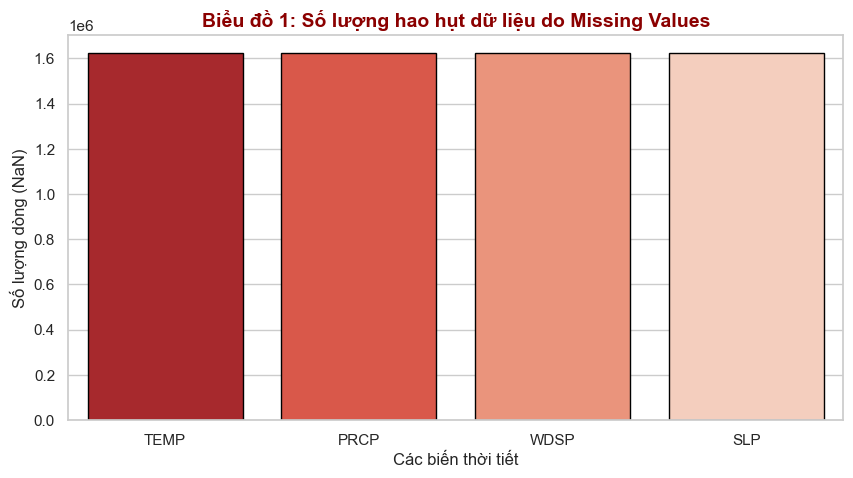

In [2]:
print("1. THỐNG KÊ LỖI THIẾU DỮ LIỆU (NaN):")
missing_counts = dirty_df[['TEMP', 'PRCP', 'WDSP', 'SLP']].isna().sum()
display(pd.DataFrame(missing_counts, columns=['Số dòng bị thiếu']))


plt.figure(figsize=(10, 5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="Reds_r", edgecolor='black')
plt.title("Biểu đồ 1: Số lượng hao hụt dữ liệu do Missing Values", fontsize=14, fontweight='bold', color='darkred')
plt.ylabel("Số lượng dòng (NaN)")
plt.xlabel("Các biến thời tiết")
plt.show()

2. PHÁT HIỆN LỖI LOGIC (Nhiệt độ -500F, Tọa độ ngoài Trái Đất):


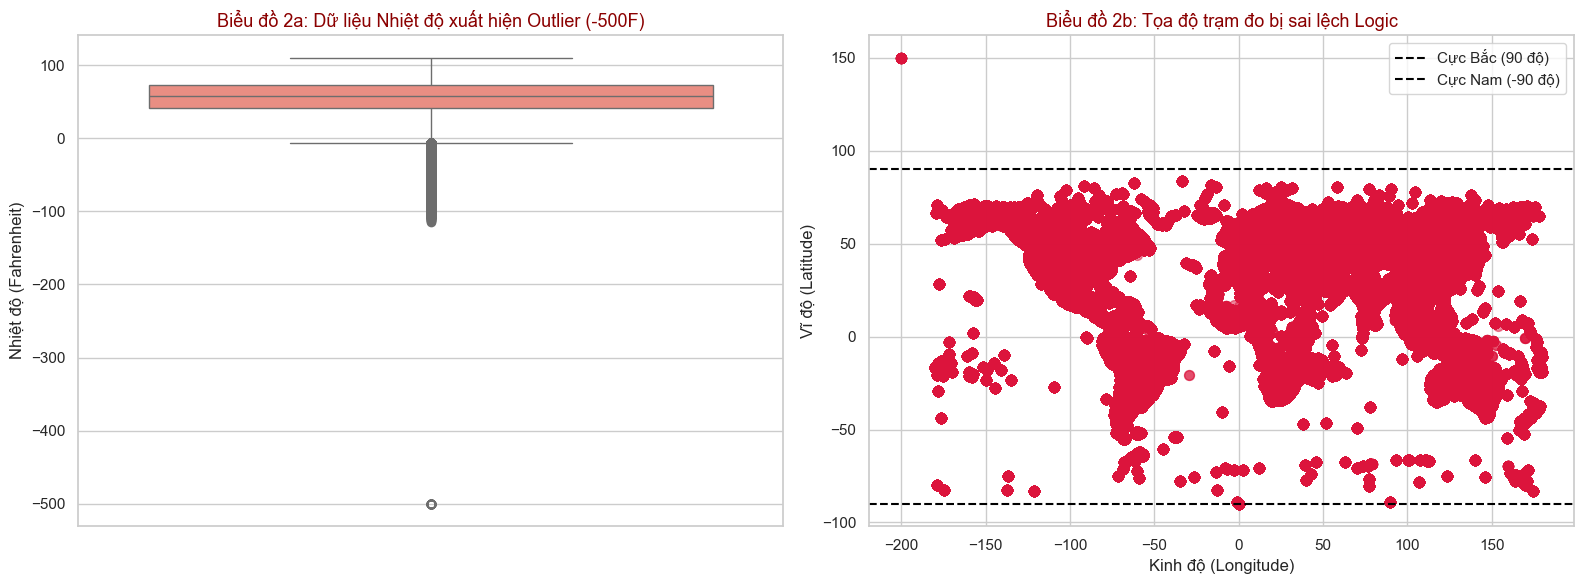

In [ ]:
dirty_df['TEMP_NUM'] = pd.to_numeric(dirty_df['TEMP'], errors='coerce')
dirty_df['LAT_NUM'] = pd.to_numeric(dirty_df['LATITUDE'], errors='coerce')
dirty_df['LON_NUM'] = pd.to_numeric(dirty_df['LONGITUDE'], errors='coerce')

print("2. PHÁT HIỆN LỖI LOGIC (Nhiệt độ -500F, Tọa độ ngoài Trái Đất):")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(y=dirty_df['TEMP_NUM'], color='salmon', ax=axes[0])
axes[0].set_title("Biểu đồ 2a: Dữ liệu Nhiệt độ xuất hiện Outlier (-500F)", fontsize=13, color='darkred')
axes[0].set_ylabel("Nhiệt độ (Fahrenheit)")

axes[1].scatter(dirty_df['LON_NUM'], dirty_df['LAT_NUM'], color='crimson', alpha=0.5, s=50)
axes[1].set_title("Biểu đồ 2b: Tọa độ trạm đo bị sai lệch Logic", fontsize=13, color='darkred')
axes[1].set_xlabel("Kinh độ (Longitude)")
axes[1].set_ylabel("Vĩ độ (Latitude)")
axes[1].axhline(90, color='black', linestyle='--', label='Cực Bắc (90 độ)')
axes[1].axhline(-90, color='black', linestyle='--', label='Cực Nam (-90 độ)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

print("--- TỔNG QUAN KIỂU DỮ LIỆU (Dùng df.info() để bắt lỗi định dạng) ---")
dirty_df.info()

print("\n" + "="*60)

print("3. LỖI THỰC THỂ (Nhận diện tự động):")
coord_names = dirty_df.groupby(['LATITUDE', 'LONGITUDE'])['NAME'].nunique()
suspect_coords = coord_names[coord_names > 1].index

print(f"=> Phát hiện {len(suspect_coords)} tọa độ bị gán nhiều tên trạm khác nhau một cách bất thường!")
if len(suspect_coords) > 0:
    lat, lon = suspect_coords[0]
    suspect_rows = dirty_df[(dirty_df['LATITUDE'] == lat) & (dirty_df['LONGITUDE'] == lon)]
    print(f"Chi tiết tại tọa độ (Lat: {lat}, Lon: {lon}) đang chứa các tên xung đột sau:")
    display(suspect_rows[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE']].drop_duplicates())


print("\n4. LỖI ĐỊNH DẠNG (Phát hiện bằng Ép kiểu):")


invalid_dates = dirty_df[pd.to_datetime(dirty_df['DATE'], errors='coerce').isna()]
print(f"=> Cột DATE: Phát hiện {len(invalid_dates)} dòng có định dạng ngày tháng không hợp lệ.")
if len(invalid_dates) > 0:
    display(invalid_dates[['STATION', 'DATE']].head(5))


invalid_elev = dirty_df[pd.to_numeric(dirty_df['ELEVATION'], errors='coerce').isna()]
print(f"=> Cột ELEVATION: Phát hiện {len(invalid_elev)} dòng bị lẫn ký tự chữ thay vì số.")
if len(invalid_elev) > 0:
    display(invalid_elev[['STATION', 'ELEVATION']].head(3))


print("\n5. LỖI TRÙNG LẶP DỮ LIỆU:")
total_dups = dirty_df.duplicated().sum()
print(f"=> Phát hiện {total_dups} dòng bị copy trùng lặp hoàn toàn.")

if total_dups > 0:
    print("Chi tiết các cặp dòng trùng lặp (hiển thị kề nhau để đối chiếu):")
    duplicates_mask = dirty_df.duplicated(keep=False) 
    
  
    dups_df = dirty_df[duplicates_mask].sort_values(by=['STATION', 'DATE'])
    display(dups_df[['STATION', 'DATE', 'NAME', 'TEMP', 'ELEVATION']].head(6))

--- TỔNG QUAN KIỂU DỮ LIỆU (Dùng df.info() để bắt lỗi định dạng) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16218047 entries, 0 to 16218046
Data columns (total 28 columns):
 #   Column            Dtype  
---  ------            -----  
 0   STATION           object 
 1   DATE              object 
 2   LATITUDE          float64
 3   LONGITUDE         float64
 4   ELEVATION         object 
 5   NAME              object 
 6   TEMP              float64
 7   TEMP_ATTRIBUTES   int64  
 8   DEWP              float64
 9   DEWP_ATTRIBUTES   int64  
 10  SLP               float64
 11  SLP_ATTRIBUTES    int64  
 12  STP               float64
 13  STP_ATTRIBUTES    int64  
 14  VISIB             float64
 15  VISIB_ATTRIBUTES  int64  
 16  WDSP              float64
 17  WDSP_ATTRIBUTES   int64  
 18  MXSPD             float64
 19  GUST              float64
 20  MAX               float64
 21  MAX_ATTRIBUTES    object 
 22  MIN               float64
 23  MIN_ATTRIBUTES    object 
 24  PRCP 

,STATION,NAME,LATITUDE,LONGITUDE
3637664,93780099999,"CHRISTCHURCH INTERNATIONAL, NZ",-43.489358,172.532225
3637889,93780099999,"ATLANTIS_CITY, OCEAN",-43.489358,172.532225



4. LỖI ĐỊNH DẠNG (Phát hiện bằng Ép kiểu):
=> Cột DATE: Phát hiện 5 dòng có định dạng ngày tháng không hợp lệ.


,STATION,DATE
2176316,70200026617,2020/31/12
2791043,72267603035,12-31-2020
2805064,72282003949,UNKNOWN
10701598,72073800267,2020-02-30
15106649,72636014840,-2020-01-01


=> Cột ELEVATION: Phát hiện 1450 dòng bị lẫn ký tự chữ thay vì số.


,STATION,ELEVATION
386822,06605099999,High
1133622,29332099999,High
1271277,35394699999,High



5. LỖI TRÙNG LẶP DỮ LIỆU:
=> Phát hiện 10 dòng bị copy trùng lặp hoàn toàn.
Chi tiết các cặp dòng trùng lặp (hiển thị kề nhau để đối chiếu):


,STATION,DATE,NAME,TEMP,ELEVATION
1248865,34363099999,2019-02-03,"KAMYSIN, RS",17.8,119.0
16218037,34363099999,2019-02-03,"KAMYSIN, RS",17.8,119.0
9880058,50745099999,2021-03-24,"SANJIAZI, CH",42.6,145.38
16218042,50745099999,2021-03-24,"SANJIAZI, CH",42.6,145.38
9958102,56946099999,2021-04-07,"GENGMA, CH",68.0,1104.0
16218038,56946099999,2021-04-07,"GENGMA, CH",68.0,1104.0


In [ ]:
print("ĐANG TIẾN HÀNH LÀM SẠCH DỮ LIỆU...")
clean_df = dirty_df.copy()

clean_df = clean_df.drop_duplicates(ignore_index=True)

clean_df['ELEVATION'] = pd.to_numeric(clean_df['ELEVATION'], errors='coerce')
clean_df['DATE'] = pd.to_datetime(clean_df['DATE'], errors='coerce')
clean_df = clean_df.dropna(subset=['DATE'])


for col in ['TEMP', 'LATITUDE', 'LONGITUDE', 'WDSP', 'PRCP', 'SLP']:
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

clean_df.loc[clean_df['TEMP'] < -100, 'TEMP'] = np.nan 
clean_df.loc[(clean_df['LATITUDE'] > 90) | (clean_df['LATITUDE'] < -90), 'LATITUDE'] = np.nan
clean_df.loc[(clean_df['LONGITUDE'] > 180) | (clean_df['LONGITUDE'] < -180), 'LONGITUDE'] = np.nan

clean_df.loc[clean_df['NAME'] == "ATLANTIS_CITY, OCEAN", 'NAME'] = np.nan
clean_df['NAME'] = clean_df.groupby(['LATITUDE', 'LONGITUDE'])['NAME'].transform(lambda x: x.ffill().bfill())


coords_cols = ['LATITUDE', 'LONGITUDE', 'ELEVATION']
if not clean_df[coords_cols].isna().all().all():
    imputer_knn = KNNImputer(n_neighbors=5)
    clean_df[coords_cols] = imputer_knn.fit_transform(clean_df[coords_cols])


clean_df = clean_df.sort_values(by=['STATION', 'DATE']).reset_index(drop=True)
weather_cols = ['TEMP', 'PRCP', 'WDSP', 'SLP']
for col in weather_cols:
    clean_df[col] = clean_df[col].interpolate(method='polynomial', order=2, limit_direction='both').fillna(method='bfill').fillna(method='ffill')

print("✨ HOÀN TẤT LÀM SẠCH! (Đã loại bỏ rác và lấp đầy 100% khoảng trống)")

ĐANG TIẾN HÀNH LÀM SẠCH DỮ LIỆU...
✨ HOÀN TẤT LÀM SẠCH! (Đã loại bỏ rác và lấp đầy 100% khoảng trống)


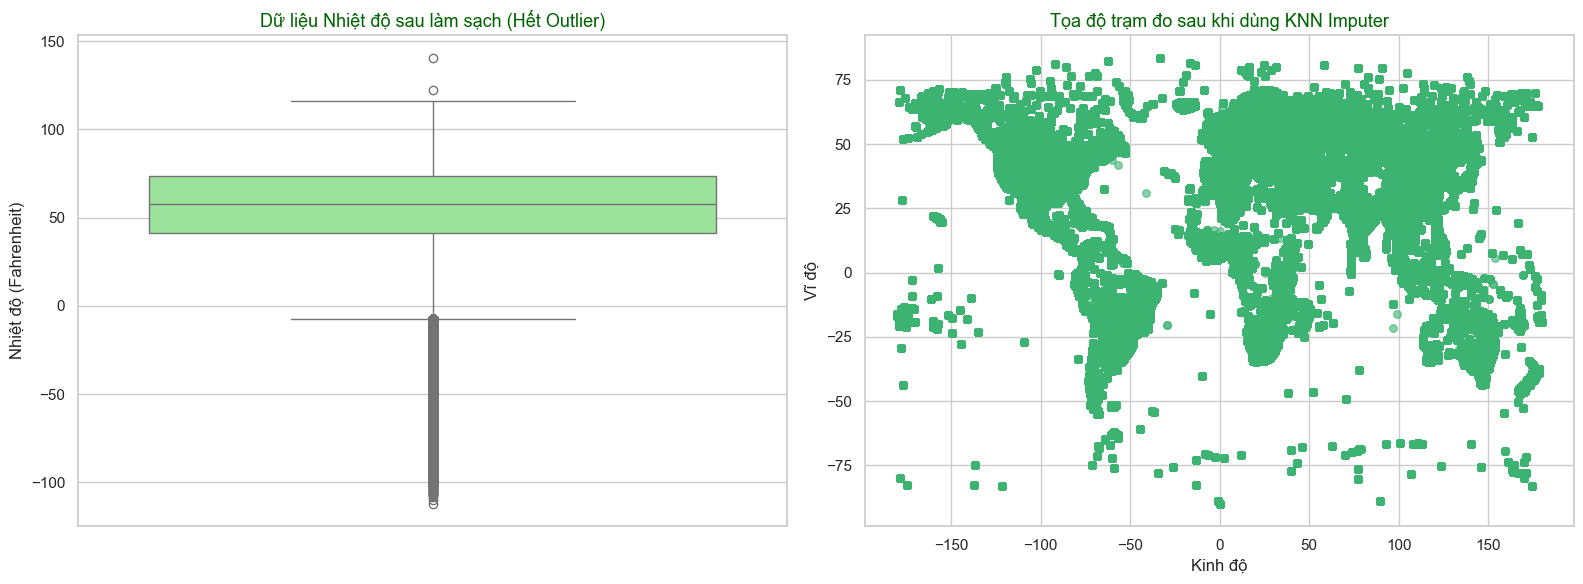

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.boxplot(y=clean_df['TEMP'], color='lightgreen', ax=axes[0])
axes[0].set_title("Dữ liệu Nhiệt độ sau làm sạch (Hết Outlier)", fontsize=13, color='darkgreen')
axes[0].set_ylabel("Nhiệt độ (Fahrenheit)")


axes[1].scatter(clean_df['LONGITUDE'], clean_df['LATITUDE'], color='mediumseagreen', alpha=0.6, s=30)
axes[1].set_title("Tọa độ trạm đo sau khi dùng KNN Imputer", fontsize=13, color='darkgreen')
axes[1].set_xlabel("Kinh độ")
axes[1].set_ylabel("Vĩ độ")

plt.tight_layout()
plt.show()

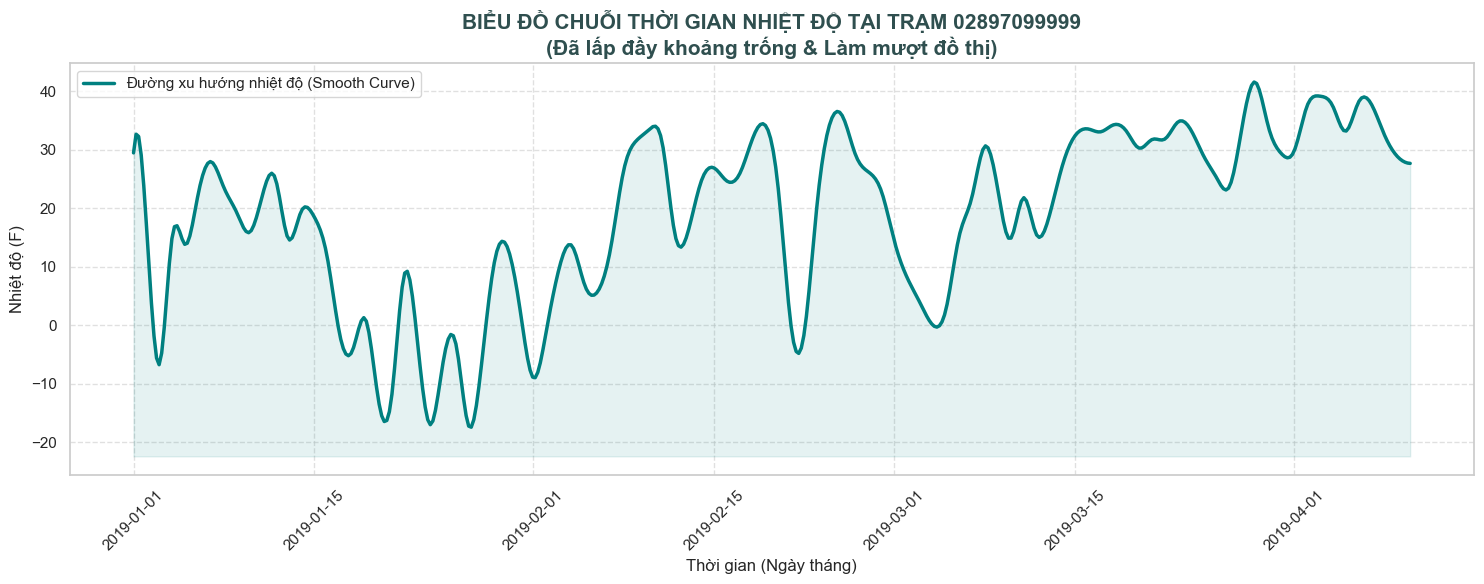

In [ ]:

top_station = clean_df['STATION'].value_counts().index[0]
ts_data = clean_df[clean_df['STATION'] == top_station].sort_values('DATE').head(100) #1st 100 days of the most complete station data


x_dates = mdates.date2num(ts_data['DATE'])
y_temps = ts_data['TEMP'].values


x_smooth = np.linspace(x_dates.min(), x_dates.max(), 500) 
spline = make_interp_spline(x_dates, y_temps, k=3) 
y_smooth = spline(x_smooth)


plt.figure(figsize=(15, 6))

plt.plot(mdates.num2date(x_smooth), y_smooth, color='teal', linewidth=2.5, 
         label='Đường xu hướng nhiệt độ (Smooth Curve)')


plt.fill_between(mdates.num2date(x_smooth), y_smooth, y_smooth.min() - 5, color='teal', alpha=0.1),
plt.title(f"BIỂU ĐỒ CHUỖI THỜI GIAN NHIỆT ĐỘ TẠI TRẠM {top_station}", 
          fontsize=15, fontweight='bold', color='darkslategray')
plt.xlabel("Thời gian (Ngày tháng)")
plt.ylabel("Nhiệt độ (F)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Lọc ra các trạm biển Đông


In [ ]:
import pandas as pd
file_path = r'C:\Users\Thich Minh Duc\Code\Preprocessing Data\Dataset\all_5_years_clean.csv' 
print(f"Đang nạp dữ liệu từ: {file_path}")

df = pd.read_csv(file_path, low_memory=False)

df['LATITUDE'] = pd.to_numeric(df['LATITUDE'], errors='coerce')
df['LONGITUDE'] = pd.to_numeric(df['LONGITUDE'], errors='coerce')

print("\nĐang quét tọa độ tìm các trạm ở khu vực Biển Đông...")

east_sea_mask = (
    (df['LATITUDE'] >= 0.0) & (df['LATITUDE'] <= 25.0) &
    (df['LONGITUDE'] >= 100.0) & (df['LONGITUDE'] <= 122.0)
)

filtered_df = df[east_sea_mask]

columns_to_keep = [
    'STATION', 'DATE', 'NAME', 'LATITUDE', 'LONGITUDE', 
    'ELEVATION', 'TEMP', 'PRCP', 'WDSP', 'SLP', 'VISIB',
    'MXSPD', 'DEWP'
]


final_cols = [col for col in columns_to_keep if col in filtered_df.columns]
filtered_df = filtered_df[final_cols]

print(f"\n=> KẾT QUẢ: Đã bắt được {len(filtered_df)} dòng dữ liệu thuộc Biển Đông!")

if not filtered_df.empty:
    display(filtered_df.head())
    
   
    output_file = 'East_Sea_Weather_Data.csv'
    filtered_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"\n Đã xuất dữ liệu các trạm Biển Đông ra file: {output_file}")
else:
    print("\nKhông có trạm nào.")

Đang nạp dữ liệu từ: C:\Users\Thich Minh Duc\Code\Preprocessing Data\Dataset\all_5_years_clean.csv

Đang quét tọa độ tìm các trạm ở khu vực Biển Đông...

=> KẾT QUẢ: Đã bắt được 396454 dòng dữ liệu thuộc Biển Đông!


,STATION,DATE,NAME,LATITUDE,LONGITUDE,ELEVATION,TEMP,PRCP,WDSP,SLP,VISIB,MXSPD,GUST,DEWP
1573801,45007099999,2019-01-01,"HONG KONG INTERNATIONAL, HK",22.308919,113.914603,8.53,55.3,0.00,9.9,9999.9,6.2,15.0,999.9,43.5
1573802,45007099999,2019-01-02,"HONG KONG INTERNATIONAL, HK",22.308919,113.914603,8.53,57.1,0.00,7.9,9999.9,6.2,11.1,999.9,45.3
1573803,45007099999,2019-01-03,"HONG KONG INTERNATIONAL, HK",22.308919,113.914603,8.53,59.9,0.00,4.4,9999.9,5.4,11.1,999.9,54.3
1573804,45007099999,2019-01-04,"HONG KONG INTERNATIONAL, HK",22.308919,113.914603,8.53,64.5,0.01,7.3,9999.9,3.1,14.0,999.9,59.6
1573805,45007099999,2019-01-05,"HONG KONG INTERNATIONAL, HK",22.308919,113.914603,8.53,64.1,0.00,8.3,9999.9,2.6,13.0,999.9,60.5



 Đã xuất dữ liệu các trạm Biển Đông ra file: East_Sea_Weather_Data.csv


Sau khi xuất dữ liệu, nhận thấy một số trạm có tình trạng thiếu dữ liệu, tiếp tục xử lí 

In [ ]:
df = pd.read_csv(r'C:\Users\Thich Minh Duc\Code\Preprocessing Data\Dataset\Global_Weather_Data\East_Sea_Weather_Data.csv')
print("Đang tiêu diệt các giá trị ảo (999.9, 9999.9)...")
df['WDSP'] = df['WDSP'].replace([999.9], np.nan)
df['MXSPD'] = df['MXSPD'].replace([999.9], np.nan)
df['GUST'] = df['GUST'].replace([999.9], np.nan)
df['PRCP'] = df['PRCP'].replace([99.99], np.nan)
df['SLP'] = df['SLP'].replace([9999.9], np.nan)

if 'GUST' in df.columns:
    df = df.drop(columns=['GUST'])
    print("=> Đã xóa cột GUST vì dữ liệu thiếu quá mức cho phép.")

print("Đang tiến hành nội suy lấp đầy SLP, WDSP, MXSPD...")
df = df.sort_values(by=['STATION', 'DATE']).reset_index(drop=True)

weather_cols = ['TEMP', 'PRCP', 'WDSP', 'MXSPD', 'SLP']
for col in weather_cols:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear', limit_direction='both')

output_file = 'East_Sea_Weather_Final.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print("\n" + "="*50)
print("TÌNH TRẠNG DỮ LIỆU SAU KHI XỬ LÝ:")
print(df[['WDSP', 'MXSPD', 'SLP']].isna().sum())
print(f"HOÀN TẤT! Dữ liệu đã sạch 100% không còn ô trống. Đã lưu vào {output_file}")